In [10]:
# ! pip install openpyxl

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
file_path = "Count.xlsx"
sheets = pd.read_excel(file_path, sheet_name=None)

# Clonogenic Assay Segmentation

### Positives vs. Ground Truth

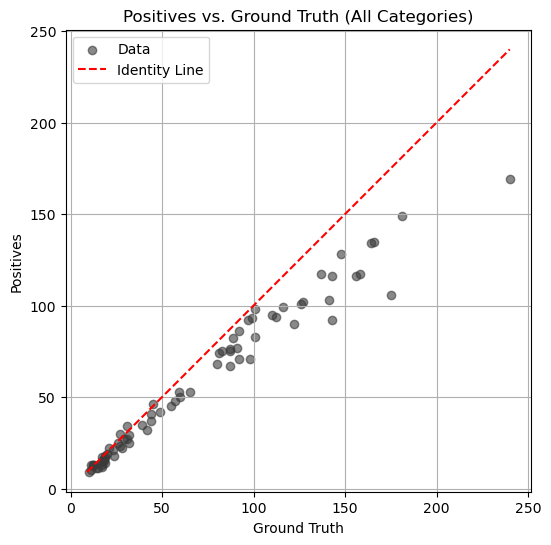

In [13]:
p_all = []
gt_all = []

# Combine all positive counts
for sheet_name, df in sheets.items():
    P = df["TP"] + df["FP"]
    p_all.append(P)
    gt_all.append(df["Ground Truth"])
    
p_combined = pd.concat(p_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

# Scatter Plot and Identity Line
plt.figure(figsize=(6, 6))
plt.scatter(gt_combined, p_combined, alpha=0.6, color="#3A3A3A", label="Data")
min_val = min(gt_combined.min(), p_combined.min())
max_val = max(gt_combined.max(), p_combined.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", label="Identity Line")

plt.xlabel("Ground Truth")
plt.ylabel("Positives")
plt.title("Positives vs. Ground Truth (All Categories)")
plt.legend()
plt.grid(True)
plt.axis("equal")  # keeps x and y scales the same
plt.savefig('./Figures/tpgt.png', dpi=300, bbox_inches='tight')
plt.show()

### False Negatives vs. Ground Truth

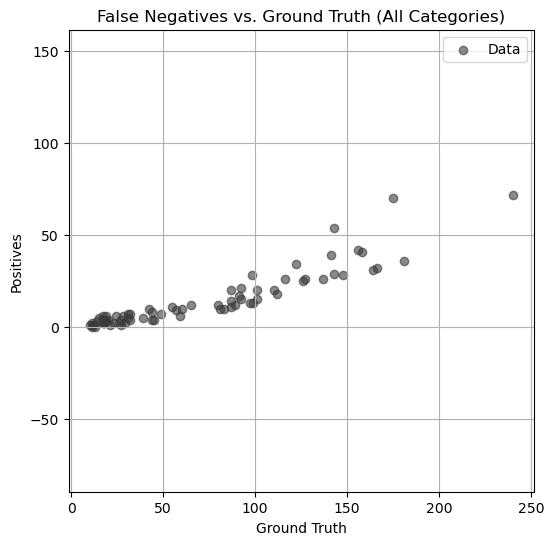

In [14]:
fn = []
gt_all = []

# Combine all false negative counts
for sheet_name, df in sheets.items():
    N = df["FN"]
    fn.append(N)
    gt_all.append(df["Ground Truth"])
    
fn_combined = pd.concat(fn, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

# Scatter Plot and Identity Line
plt.figure(figsize=(6, 6))
plt.scatter(gt_combined, fn_combined, alpha=0.6, color="#3A3A3A", label="Data")

plt.xlabel("Ground Truth")
plt.ylabel("Positives")
plt.title("False Negatives vs. Ground Truth (All Categories)")
plt.legend()
plt.grid(True)
plt.axis("equal")  # keeps x and y scales the same
plt.savefig('./Figures/fngt.png', dpi=300, bbox_inches='tight')
plt.show()

### False Positives vs. Ground Truth

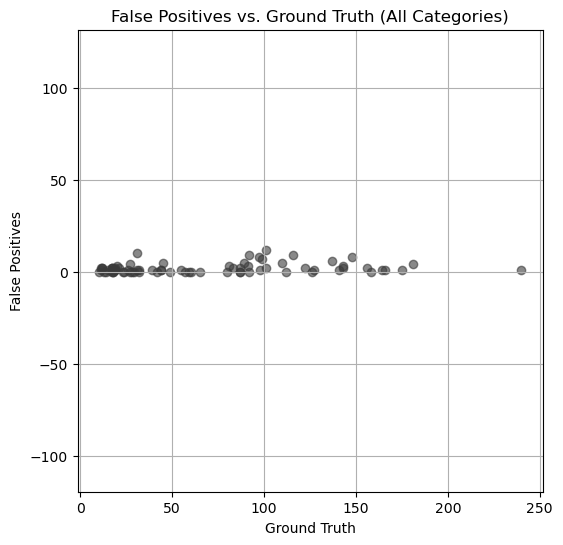

In [15]:
fp_all = []
gt_all = []

# Combine all false positives counts
for sheet_name, df in sheets.items():
    fp_all.append(df["FP"])
    gt_all.append(df["Ground Truth"])
fp_combined = pd.concat(fp_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(gt_combined, fp_combined, alpha=0.6, color="#3A3A3A", label="Data")

plt.xlabel("Ground Truth")
plt.ylabel("False Positives")
plt.title("False Positives vs. Ground Truth (All Categories)")
plt.grid(True)
plt.axis("equal")
plt.savefig('./Figures/fpgt.png', dpi=300, bbox_inches='tight')
plt.show()

### Kernel Density Estimate

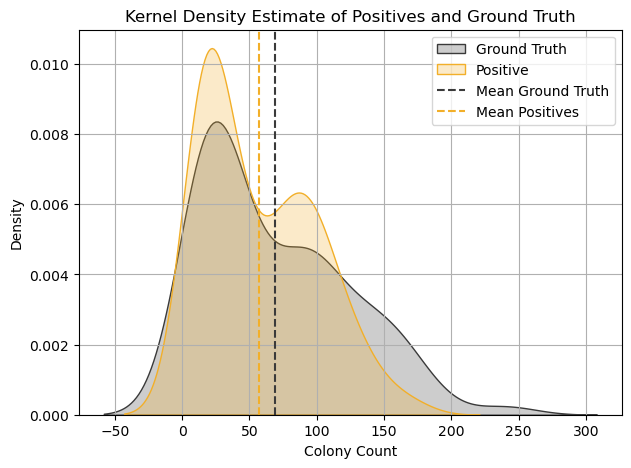

In [16]:
p_all = []
gt_all = []

for df in sheets.values():
    P = df["TP"] + df["FP"]
    p_all.append(P)
    gt_all.append(df["Ground Truth"])

p_combined = pd.concat(p_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

mean_p = p_combined.mean()
mean_gt = gt_combined.mean()

plt.figure(figsize=(7, 5))

# KDE plots
sns.kdeplot(gt_combined, color="#3A3A3A", label="Ground Truth", fill=True)
sns.kdeplot(p_combined, color="#F2AF29", label="Positive", fill=True)

# Mean lines
plt.axvline(mean_gt, color="#3A3A3A", linestyle="--", label="Mean Ground Truth")
plt.axvline(mean_p, color="#F2AF29", linestyle="--", label="Mean Positives")

plt.xlabel("Colony Count")
plt.ylabel("Density")
plt.title("Kernel Density Estimate of Positives and Ground Truth")
plt.legend()
plt.grid(True)
plt.savefig('./Figures/density.png', dpi=300, bbox_inches='tight')
plt.show()

# SegmentAnything

### Positives vs. Ground Truth

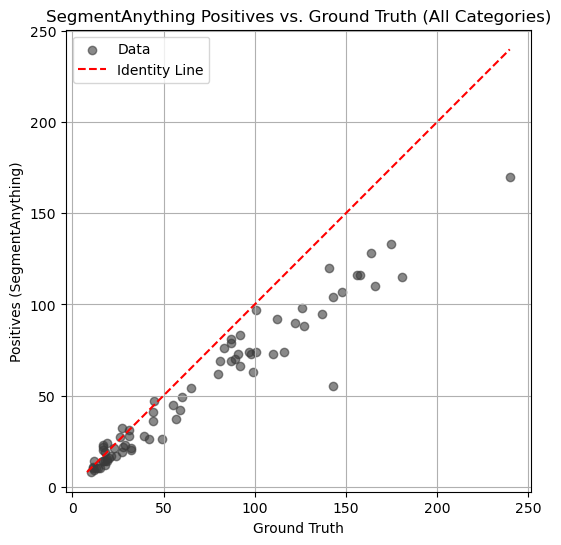

In [17]:
p_all = []
gt_all = []

# Combine all positive counts
for sheet_name, df in sheets.items():
    P = df["TP (SegA)"] + df["FP (SegA)"]
    p_all.append(P)
    gt_all.append(df["Ground Truth"])

p_combined = pd.concat(p_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)


# Scatter Plot and Identity Line
plt.figure(figsize=(6, 6))
plt.scatter(gt_combined, p_combined, alpha=0.6, color="#3A3A3A", label="Data")
min_val = min(gt_combined.min(), p_combined.min())
max_val = max(gt_combined.max(), p_combined.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linestyle="--", label="Identity Line")

plt.xlabel("Ground Truth")
plt.ylabel("Positives (SegmentAnything)")
plt.title("SegmentAnything Positives vs. Ground Truth (All Categories)")
plt.legend()
plt.grid(True)
plt.axis("equal")  # keeps x and y scales the same
plt.savefig('./Figures/tpgtSegA.png', dpi=300, bbox_inches='tight')
plt.show()

### False Negatives vs. Ground Truth

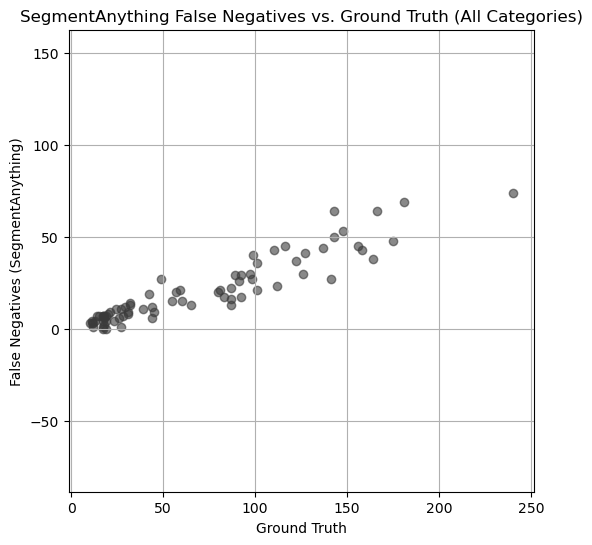

In [18]:
fn_all = []
gt_all = []

# Combine all false negatives counts
for sheet_name, df in sheets.items():
    fn_all.append(df["FN (SegA)"])
    gt_all.append(df["Ground Truth"])

fn_combined = pd.concat(fn_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(gt_combined, fn_combined, alpha=0.6, color="#3A3A3A", label="Data")

plt.xlabel("Ground Truth")
plt.ylabel("False Negatives (SegmentAnything)")
plt.title("SegmentAnything False Negatives vs. Ground Truth (All Categories)")
plt.grid(True)
plt.axis("equal")
plt.savefig('./Figures/fngtSegA.png', dpi=300, bbox_inches='tight')
plt.show()

### False Positives vs. Ground Truth

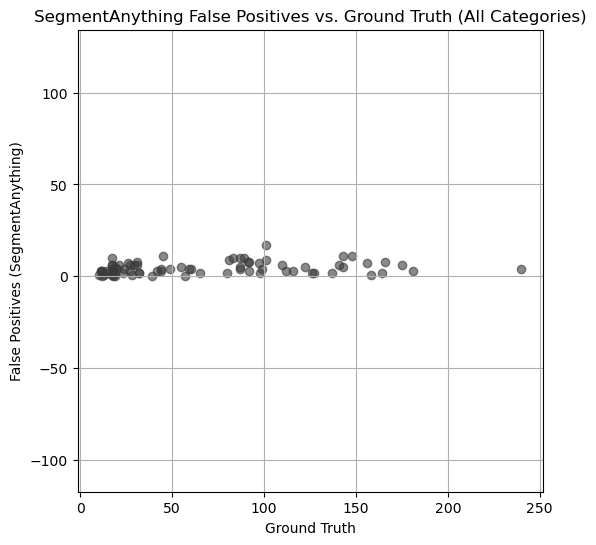

In [19]:
fp_all = []
gt_all = []

# Combine all false positives counts
for sheet_name, df in sheets.items():
    fp_all.append(df["FP (SegA)"])
    gt_all.append(df["Ground Truth"])
fp_combined = pd.concat(fp_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(gt_combined, fp_combined, alpha=0.6, color="#3A3A3A", label="Data")

plt.xlabel("Ground Truth")
plt.ylabel("False Positives (SegmentAnything)")
plt.title("SegmentAnything False Positives vs. Ground Truth (All Categories)")
plt.grid(True)
plt.axis("equal")
plt.savefig('./Figures/fpgtSegA.png', dpi=300, bbox_inches='tight')
plt.show()

### Kernel Density Estimate

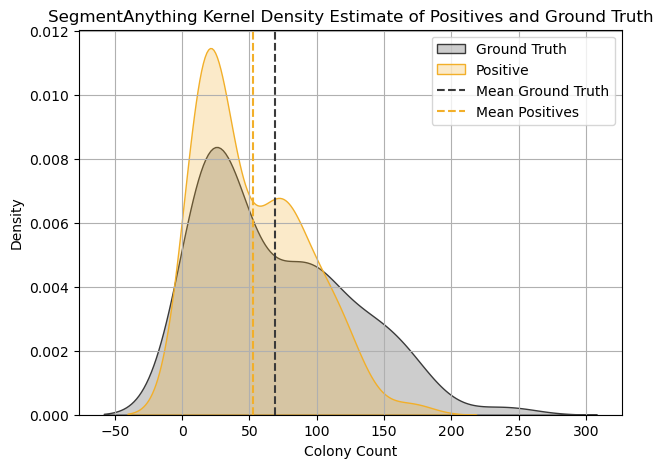

In [20]:
p_all = []
gt_all = []

for df in sheets.values():
    P = df["TP (SegA)"] + df["FP (SegA)"]
    p_all.append(P)
    gt_all.append(df["Ground Truth"])

p_combined = pd.concat(p_all, ignore_index=True)
gt_combined = pd.concat(gt_all, ignore_index=True)

mean_p = p_combined.mean()
mean_gt = gt_combined.mean()

plt.figure(figsize=(7, 5))

# KDE plots
sns.kdeplot(gt_combined, color="#3A3A3A", label="Ground Truth", fill=True)
sns.kdeplot(p_combined, color="#F2AF29", label="Positive", fill=True)

# Mean lines
plt.axvline(mean_gt, color="#3A3A3A", linestyle="--", label="Mean Ground Truth")
plt.axvline(mean_p, color="#F2AF29", linestyle="--", label="Mean Positives")

plt.xlabel("Colony Count")
plt.ylabel("Density")
plt.title("SegmentAnything Kernel Density Estimate of Positives and Ground Truth")
plt.legend()
plt.grid(True)
plt.savefig('./Figures/densitySegA.png', dpi=300, bbox_inches='tight')
plt.show()